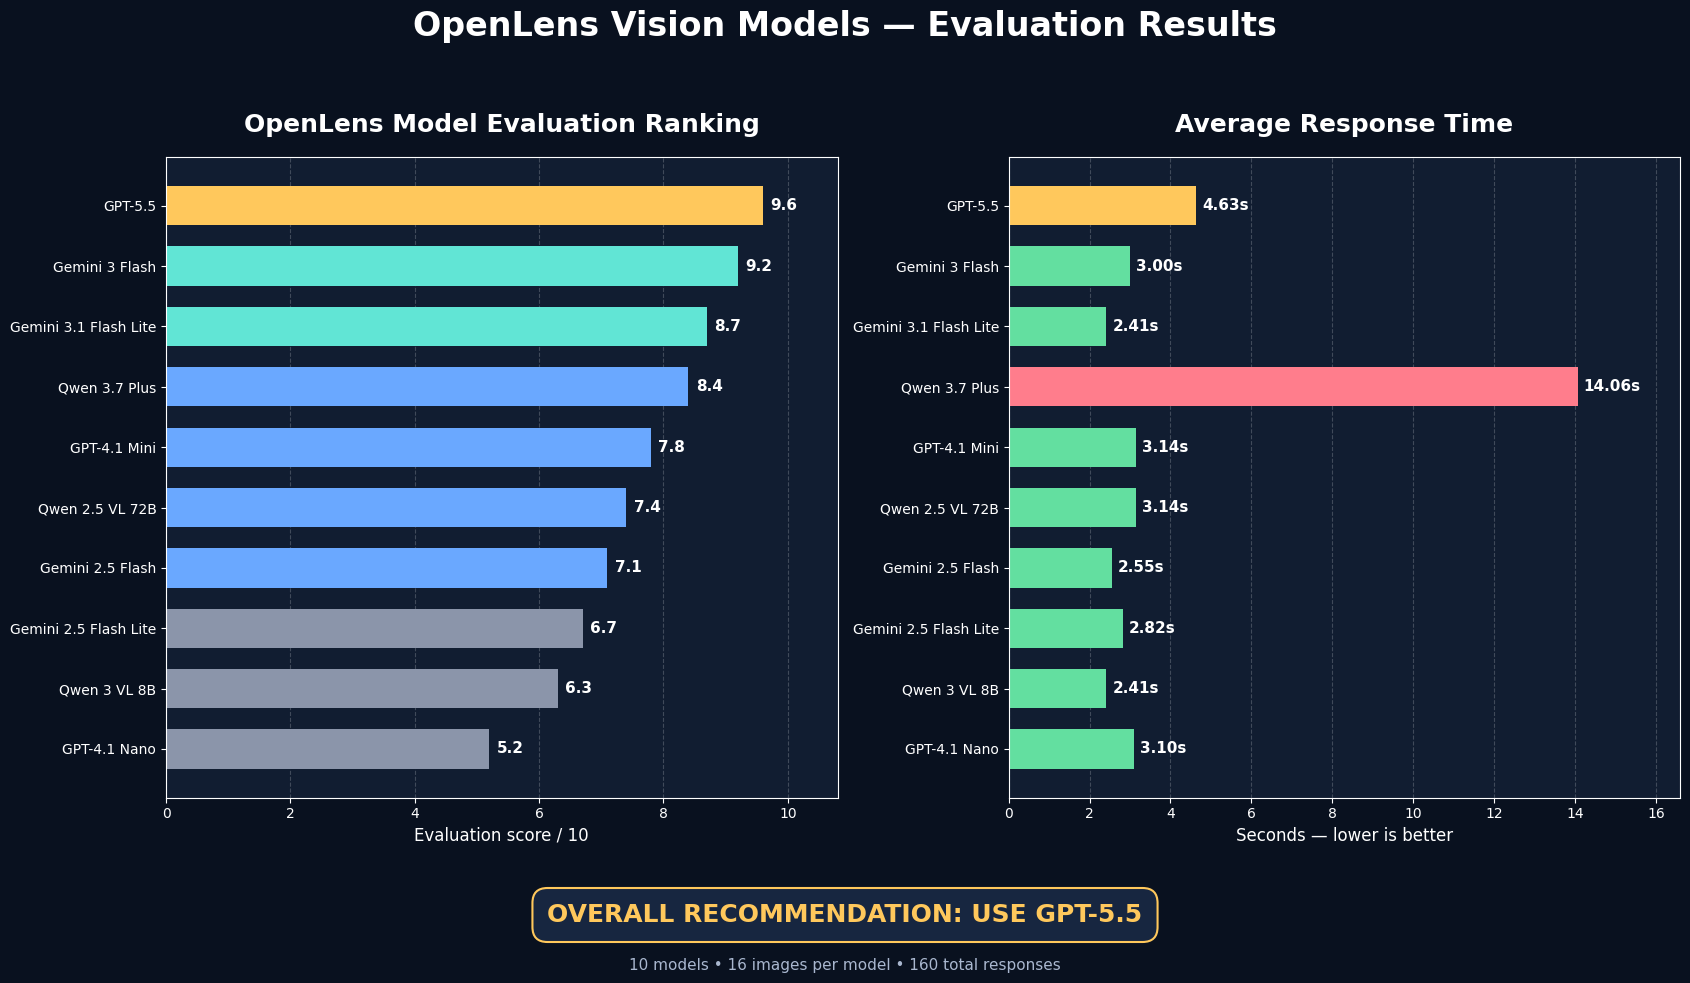

Graph saved to: C:\Users\ROG\openlens\model_evaluation_results.png


In [ ]:
# SCROLL DOWN FOR THE RESULTS!

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


RESULTS_FOLDER = Path("../ModelResults")
OUTPUT_FILE = Path("../model_evaluation_results.png")

MODEL_EVALUATIONS = {
    "GPT-5.5": {
        "file": "submission_gpt_5_5.csv",
        "score": 9.6,
    },
    "Gemini 3 Flash": {
        "file": "submission_gemini_3_flash.csv",
        "score": 9.2,
    },
    "Gemini 3.1 Flash Lite": {
        "file": "submission_gemini_3_1_flash_lite.csv",
        "score": 8.7,
    },
    "Qwen 3.7 Plus": {
        "file": "submission_qwen_3_7_plus.csv",
        "score": 8.4,
    },
    "GPT-4.1 Mini": {
        "file": "submission_gpt_4_1_mini.csv",
        "score": 7.8,
    },
    "Qwen 2.5 VL 72B": {
        "file": "submission_qwen_2_5_vl_72b.csv",
        "score": 7.4,
    },
    "Gemini 2.5 Flash": {
        "file": "submission_gemini_2_5_flash.csv",
        "score": 7.1,
    },
    "Gemini 2.5 Flash Lite": {
        "file": "submission_gemini_2_5_flash_lite.csv",
        "score": 6.7,
    },
    "Qwen 3 VL 8B": {
        "file": "submission_qwen_3_vl_8b.csv",
        "score": 6.3,
    },
    "GPT-4.1 Nano": {
        "file": "submission_gpt_4_1_nano.csv",
        "score": 5.2,
    },
}


results = []

for model_name, model_data in MODEL_EVALUATIONS.items():
    csv_path = RESULTS_FOLDER / model_data["file"]

    if not csv_path.exists():
        print(f"Missing file: {csv_path}")
        continue

    dataframe = pd.read_csv(csv_path)

    average_time = dataframe[
        "response_time_seconds"
    ].mean()

    if "status" in dataframe.columns:
        successful_requests = (
            dataframe["status"].eq("success").sum()
        )
    else:
        successful_requests = len(dataframe)

    results.append(
        {
            "model": model_name,
            "evaluation_score": model_data["score"],
            "average_response_time": average_time,
            "successful_requests": successful_requests,
        }
    )


results_df = pd.DataFrame(results).sort_values(
    "evaluation_score",
    ascending=True,
)

models = results_df["model"]
scores = results_df["evaluation_score"]
response_times = results_df["average_response_time"]

plt.style.use("dark_background")

figure, axes = plt.subplots(
    1,
    2,
    figsize=(17, 10),
)

figure.patch.set_facecolor("#09111f")

for axis in axes:
    axis.set_facecolor("#111d31")
    axis.grid(
        axis="x",
        linestyle="--",
        alpha=0.2,
    )
    axis.set_axisbelow(True)


score_colors = [
    "#ffc85c"
    if score == scores.max()
    else "#61e5d5"
    if score >= 8.5
    else "#6aa8ff"
    if score >= 7
    else "#8b95aa"
    for score in scores
]

score_bars = axes[0].barh(
    models,
    scores,
    color=score_colors,
    edgecolor="none",
    height=0.65,
)

axes[0].set_title(
    "OpenLens Model Evaluation Ranking",
    fontsize=18,
    fontweight="bold",
    pad=18,
)

axes[0].set_xlabel(
    "Evaluation score / 10",
    fontsize=12,
)

axes[0].set_xlim(0, 10.8)

for bar, score in zip(score_bars, scores):
    axes[0].text(
        score + 0.12,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.1f}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )


time_colors = [
    "#ff7d8c"
    if value > 10
    else "#ffc85c"
    if value > 4
    else "#63dfa0"
    for value in response_times
]

time_bars = axes[1].barh(
    models,
    response_times,
    color=time_colors,
    edgecolor="none",
    height=0.65,
)

axes[1].set_title(
    "Average Response Time",
    fontsize=18,
    fontweight="bold",
    pad=18,
)

axes[1].set_xlabel(
    "Seconds — lower is better",
    fontsize=12,
)

axes[1].set_xlim(
    0,
    response_times.max() * 1.18,
)

for bar, response_time in zip(
    time_bars,
    response_times,
):
    axes[1].text(
        response_time + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{response_time:.2f}s",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )


figure.suptitle(
    "OpenLens Vision Models — Evaluation Results",
    fontsize=24,
    fontweight="bold",
    color="white",
    y=0.98,
)

figure.text(
    0.5,
    0.075,
    "OVERALL RECOMMENDATION: USE GPT-5.5",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="#ffc85c",
    bbox={
        "boxstyle": "round,pad=0.6",
        "facecolor": "#172640",
        "edgecolor": "#ffc85c",
        "linewidth": 1.5,
    },
)

figure.text(
    0.5,
    0.02,
    "10 models • 16 images per model • "
    "160 total responses",
    ha="center",
    fontsize=11,
    color="#a9b7cf",
)

plt.tight_layout(
    rect=[0, 0.13, 1, 0.94],
)

plt.savefig(
    OUTPUT_FILE,
    dpi=300,
    bbox_inches="tight",
    facecolor=figure.get_facecolor(),
)

plt.show()

print(f"Graph saved to: {OUTPUT_FILE.resolve()}")